# Copartidários por lista: operacionalização de Crisp et al. (2007)

## Contexto conceitual

Carey & Shugart (1995) identificam que os incentivos a cultivar uma reputação
pessoal dependem da razão entre copartidários competindo e vagas disponíveis.
O conceito correto é **C:M** — número de candidatos do partido na lista (C)
dividido pela magnitude do distrito (M). Mas ao operacionalizar, os próprios
autores justificaram usar apenas M como proxy, argumentando que "o número de
endossos tende a crescer com M" (p. 431). A literatura subsequente adotou M
universalmente.

Crisp et al. (2007) mostram dois problemas:

1. **C e M crescem juntos, mas C:M na verdade *cai* com M** — C cresce a uma taxa
   *menor* que M, então a razão diminui à medida que o distrito fica maior. Usar
   M como proxy inverte o sentido empírico da relação.

2. **C varia entre partidos no mesmo distrito** — M é constante por distrito, mas
   C difere por partido. Um proxy de nível distrital não captura variação
   intradistrital.

A solução proposta é a razão **C:P**, onde P é o número de cadeiras que o partido
*provavelmente vai ganhar* (partido × UF). O denominador correto não é o total
de vagas do distrito, mas as vagas que o partido tende a conquistar: candidatos
competem entre si pelas *cadeiras do seu partido*, não pelas cadeiras do
distrito. Como estimativa de P, os autores usam as cadeiras conquistadas pelo
partido na eleição anterior.

**Implicação para sistemas de lista aberta:** quanto maior C:P, mais o candidato
precisa de uma reputação pessoal para se distinguir entre copartidários que
disputam as mesmas vagas. Partidos pequenos em qualquer distrito têm C:P alto
(muitos candidatos para poucas vagas prováveis). Partidos fortes em seus
redutos têm C:P mais baixo (as vagas são muitas relativas aos candidatos).

---
Este notebook:
1. Extrai P (cadeiras por partido × UF) das eleições anteriores (`resultados.parquet`)
2. Constrói a base por lista com C, M, C:M e C:P
3. Descreve a distribuição de cada medida
4. Apresenta recortes por **UF** e por **partido**
5. Compara as três proxies: M, C:M e C:P

In [1]:
import os
from pathlib import Path
ROOT = Path().resolve().parent  # notebooks/ -> project root
os.chdir(ROOT)
import sys
sys.path.insert(0, str(ROOT / 'src' / '2_gold'))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from cap3_cs_features import gerar_features

PROCESSED = ROOT / 'data' / 'processed'

rrd = pd.read_parquet(PROCESSED / 'rrd_df_novo.parquet')
rrd = gerar_features(rrd)

print(f"{len(rrd):,} candidatos | anos: {sorted(rrd['ano_eleicao'].unique())}")

23,483 candidatos | anos: [np.int32(2014), np.int32(2018), np.int32(2022)]


## 1. Extração de P: cadeiras conquistadas na eleição anterior

P é estimado pelas cadeiras efetivamente ganhas pelo partido × UF na eleição
anterior:
- P para **2018** → eleição de **2014** (extraído de `resultados.parquet`)
- P para **2022** → eleição de **2018** (cruzamento interno na própria base)

Partidos que não competiram na eleição anterior ficam com P = 0 (nenhuma
cadeira esperada); sua C:P fica indefinida — tratada como `NaN`.

In [3]:
ELEITO_STATUS = ["ELEITO", "ELEITO POR MÉDIA", "MÉDIA", "ELEITO POR QP"]

resultados = pd.read_parquet(PROCESSED / 'resultados.parquet')

def cadeiras_por_lista(ano_ref):
    """Retorna DataFrame com cadeiras ganhas por partido×UF no ano_ref."""
    sub = resultados.loc[
        (resultados['ano_eleicao'] == ano_ref) &
        (resultados['ds_cargo'].str.upper().str.contains('DEPUTADO FEDERAL')) &
        (resultados['nr_turno'] == 1)
    ].copy()
    sub['eleito'] = sub['ds_sit_tot_turno'].isin(ELEITO_STATUS).astype(int)
    return (
        sub.groupby(['sg_uf', 'sg_partido'])['eleito']
        .sum()
        .reset_index()
        .rename(columns={'eleito': 'p_esperado'})
    )

p_2014 = cadeiras_por_lista(2014)  # usado como P para 2018
p_2018 = cadeiras_por_lista(2018)  # usado como P para 2022

print(f"P 2014: {len(p_2014)} combinações partido×UF | total cadeiras: {p_2014['p_esperado'].sum()}")
print(f"P 2018: {len(p_2018)} combinações partido×UF | total cadeiras: {p_2018['p_esperado'].sum()}")

P 2014: 776 combinações partido×UF | total cadeiras: 513
P 2018: 859 combinações partido×UF | total cadeiras: 513


## 2. Base por lista

Unidade: **lista** = partido × UF × ano.

| Variável | Definição |
|---|---|
| `C` (`n_cands`) | Candidatos lançados pelo partido na lista |
| `M` (`qt_vaga`) | Magnitude do distrito (vagas totais) |
| `P` (`p_esperado`) | Cadeiras esperadas = ganhas pelo partido na eleição anterior |
| `C:M` (`razao_cm`) | Proxy intermediário — Carey & Shugart (1995) |
| `C:P` (`razao_cp`) | Medida central de Crisp et al. (2007) |
| `prop_limite` | Proporção do teto legal utilizada |

In [4]:
listas = (
    rrd.groupby(['ano_eleicao', 'sg_uf', 'sg_partido'])
    .agg(
        qt_vaga          = ('qt_vaga', 'first'),
        n_cands          = ('nr_candidato', 'count'),
        n_eleitos        = ('eleito', 'sum'),
        vr_total_partido = ('vr_receita_recursos_partidos', 'sum'),
        n_receberam      = ('vr_receita_recursos_partidos', lambda x: (x > 0).sum()),
    )
    .reset_index()
)

# C:M
listas['razao_cm'] = listas['n_cands'] / listas['qt_vaga']

# Teto legal: Lei 9.504/97 (art. 10) vigente em 2018 e 2022:
# partidos isolados → 1,5 × M (independente do tamanho do distrito).
# A regra M<=20 → 2M era a redação original de 1997; reformas posteriores
# (Lei 13.165/2015) uniformizaram em 1,5M para partidos, 2M para coligações.
# Como rrd filtra candidatos individuais (não coligações agregadas), usamos 1,5M.
listas['limite_legal'] = 1.5 * listas['qt_vaga']
listas['prop_limite']  = listas['n_cands'] / listas['limite_legal']

# P: merge com cadeiras da eleição anterior
listas_2018 = listas.loc[listas['ano_eleicao'] == 2018].merge(
    p_2014, on=['sg_uf', 'sg_partido'], how='left'
)
listas_2022 = listas.loc[listas['ano_eleicao'] == 2022].merge(
    p_2018, on=['sg_uf', 'sg_partido'], how='left'
)
listas = pd.concat([listas_2018, listas_2022], ignore_index=True)

# C:P — indefinido quando P = 0 (partido sem cadeira anterior na UF)
listas['razao_cp'] = np.where(
    listas['p_esperado'] > 0,
    listas['n_cands'] / listas['p_esperado'],
    np.nan
)

listas['recebeu_fefc'] = (listas['vr_total_partido'] > 0).astype(int)

print(f"{len(listas):,} listas  |  2018: {(listas.ano_eleicao==2018).sum()}  |  2022: {(listas.ano_eleicao==2022).sum()}")
print(f"C:P disponível: 2018={listas.loc[listas.ano_eleicao==2018,'razao_cp'].notna().sum()} "
      f"| 2022={listas.loc[listas.ano_eleicao==2022,'razao_cp'].notna().sum()}")
listas[['ano_eleicao','sg_uf','sg_partido','n_cands','qt_vaga','p_esperado',
        'razao_cm','razao_cp','prop_limite']].head(10)

1,570 listas  |  2018: 859  |  2022: 711
C:P disponível: 2018=226 | 2022=198


,ano_eleicao,sg_uf,sg_partido,n_cands,qt_vaga,p_esperado,razao_cm,razao_cp,prop_limite
0,2018,AC,AVANTE,9,8,NaN,1.125,NaN,0.750000
1,2018,AC,DC,3,8,NaN,0.375,NaN,0.250000
2,2018,AC,DEM,1,8,0.0,0.125,NaN,0.083333
3,2018,AC,MDB,3,8,NaN,0.375,NaN,0.250000
4,2018,AC,PATRI,1,8,NaN,0.125,NaN,0.083333
5,2018,AC,PC do B,1,8,0.0,0.125,NaN,0.083333
6,2018,AC,PDT,16,8,0.0,2.000,NaN,1.333333
7,2018,AC,PHS,2,8,0.0,0.250,NaN,0.166667
8,2018,AC,PMB,1,8,NaN,0.125,NaN,0.083333
9,2018,AC,PMN,1,8,0.0,0.125,NaN,0.083333


## 3. Distribuição das medidas de competição intrapartidária

In [5]:
desc = (
    listas.groupby('ano_eleicao')[['qt_vaga','n_cands','p_esperado','razao_cm','razao_cp','prop_limite']]
    .describe(percentiles=[.25,.5,.75,.95])
    .round(3)
)
desc

qt_vaga                                                   n_cands  \
              count    mean     std  min  25%   50%   75%   95%   max   count   
ano_eleicao                                                                     
2018          859.0  19.462  16.247  8.0  8.0  10.0  25.0  53.0  70.0   859.0   
2022          711.0  20.589  16.804  8.0  8.0  12.0  30.0  53.0  70.0   711.0   

             ... razao_cp prop_limite                                     \
             ...      max       count   mean    std    min    25%    50%   
ano_eleicao  ...                                                           
2018         ...     82.0       859.0  0.284  0.238  0.014  0.087  0.200   
2022         ...     59.0       711.0  0.469  0.238  0.010  0.250  0.533   

                                  
               75%    95%    max  
ano_eleicao                       
2018         0.400  0.783  1.333  
2022         0.667  0.750  0.750  

[2 rows x 54 columns]

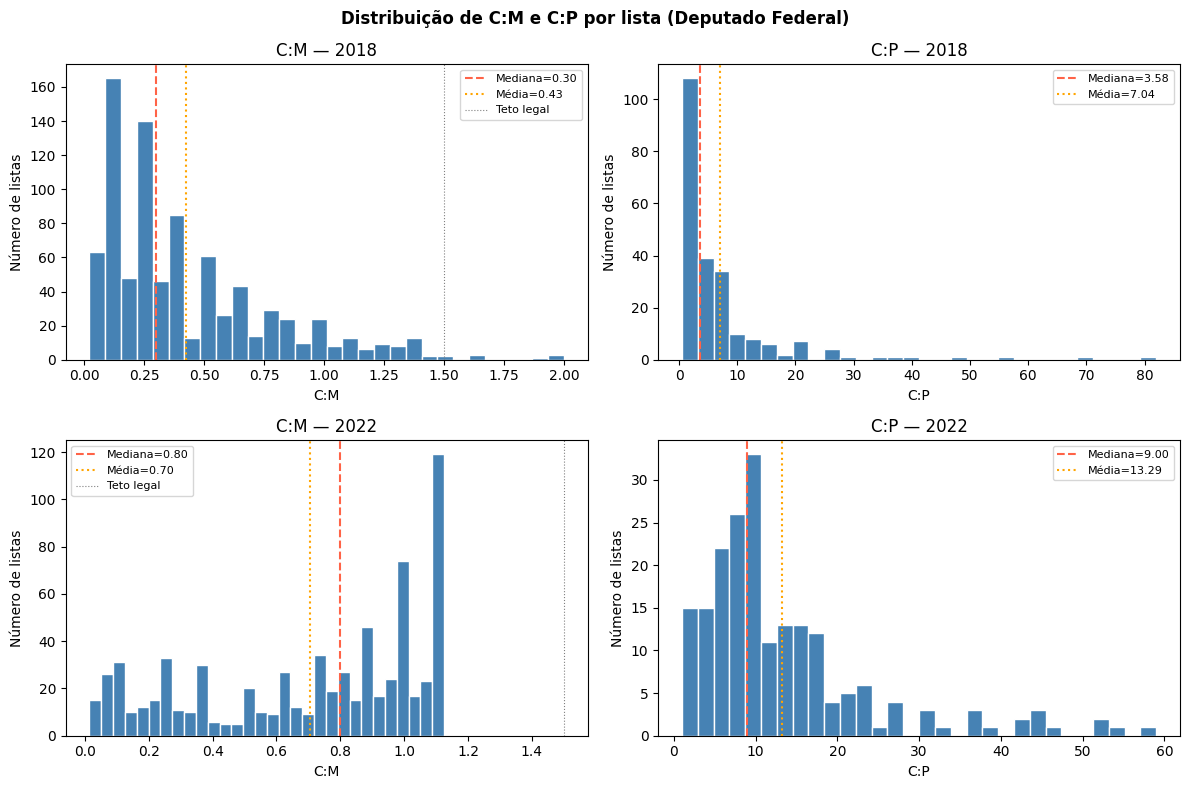

In [6]:
# C:M vs C:P — diferença de escala e distribuição
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col_idx, (col, label) in enumerate([('razao_cm', 'C:M'), ('razao_cp', 'C:P')]):
    for row_idx, ano in enumerate([2018, 2022]):
        ax = axes[row_idx, col_idx]
        sub = listas.loc[listas['ano_eleicao'] == ano, col].dropna()
        ax.hist(sub, bins=30, edgecolor='white', color='steelblue')
        ax.axvline(sub.median(), color='tomato', linestyle='--', label=f'Mediana={sub.median():.2f}')
        ax.axvline(sub.mean(),   color='orange', linestyle=':',  label=f'Média={sub.mean():.2f}')
        if col == 'razao_cm':
            ax.axvline(1.5, color='gray', linestyle=':', linewidth=0.8, label='Teto legal')
        ax.set_title(f'{label} — {ano}')
        ax.set_xlabel(label)
        ax.set_ylabel('Número de listas')
        ax.legend(fontsize=8)

fig.suptitle('Distribuição de C:M e C:P por lista (Deputado Federal)', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Correlações entre as três proxies
print("Correlações (Pearson) entre proxies de competição intrapartidária:\n")
for ano in [2018, 2022]:
    sub = listas.loc[listas['ano_eleicao'] == ano, ['qt_vaga','razao_cm','razao_cp']].dropna()
    print(f"--- {ano} (n={len(sub)}) ---")
    print(sub.corr().round(4))
    print()

Correlações (Pearson) entre proxies de competição intrapartidária:

--- 2018 (n=226) ---
          qt_vaga  razao_cm  razao_cp
qt_vaga    1.0000    0.0787    0.3965
razao_cm   0.0787    1.0000    0.5704
razao_cp   0.3965    0.5704    1.0000

--- 2022 (n=198) ---
          qt_vaga  razao_cm  razao_cp
qt_vaga     1.000   -0.1710    0.5640
razao_cm   -0.171    1.0000    0.2796
razao_cp    0.564    0.2796    1.0000



C:\Users\yuri_taba\AppData\Local\Temp\ipykernel_4440\2889826044.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot(xs, res_ols.params[0] + res_ols.params[1]*xs,
C:\Users\yuri_taba\AppData\Local\Temp\ipykernel_4440\2889826044.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f'β={res_ols.params[1]:.4f}, R²={res_ols.rsquared:.3f}')
C:\Users\yuri_taba\AppData\Local\Temp\ipykernel_4440\2889826044.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by 

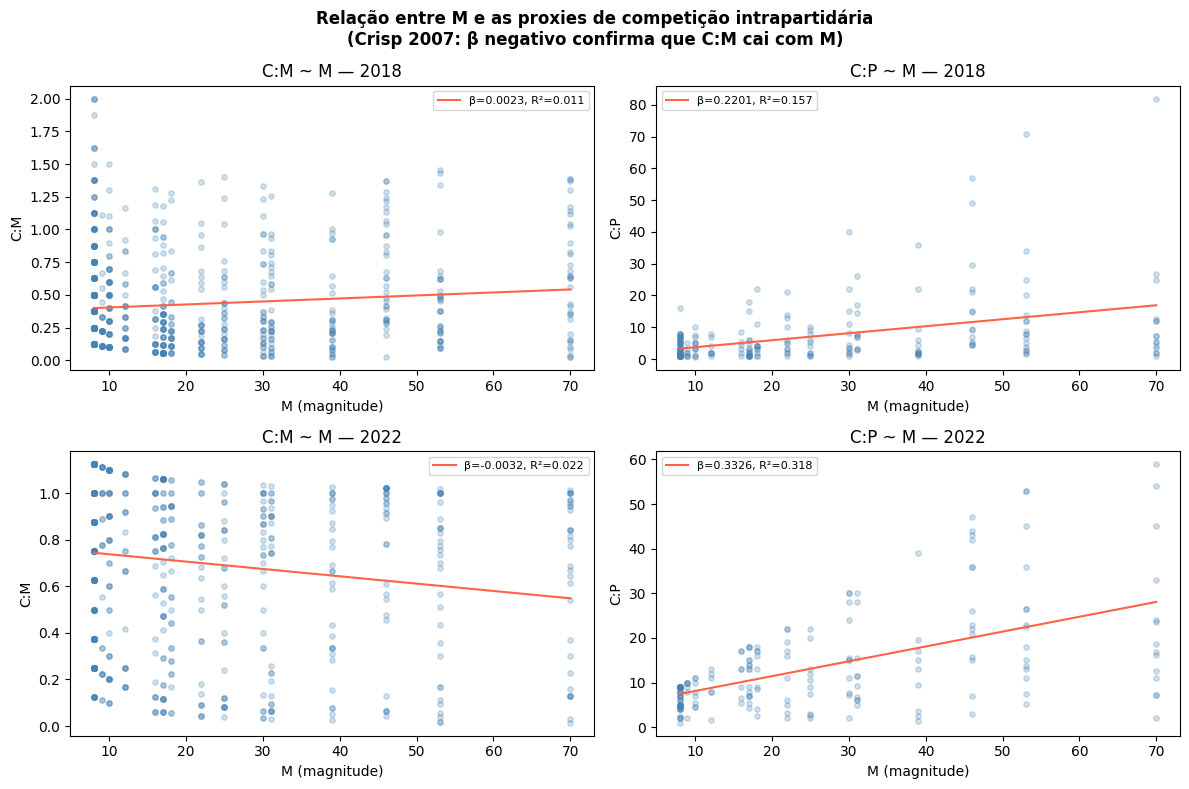

In [8]:
# Scatter M × C:M e M × C:P — argumento central de Crisp: C:M cai com M
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col_idx, (col, label) in enumerate([('razao_cm', 'C:M'), ('razao_cp', 'C:P')]):
    for row_idx, ano in enumerate([2018, 2022]):
        ax = axes[row_idx, col_idx]
        sub = listas.loc[listas['ano_eleicao'] == ano].dropna(subset=[col])
        ax.scatter(sub['qt_vaga'], sub[col], alpha=0.25, s=15, color='steelblue')
        # Tendência OLS
        X = sm.add_constant(sub['qt_vaga'])
        res_ols = sm.OLS(sub[col], X).fit()
        xs = np.linspace(sub['qt_vaga'].min(), sub['qt_vaga'].max(), 200)
        ax.plot(xs, res_ols.params[0] + res_ols.params[1]*xs,
                color='tomato', linewidth=1.5,
                label=f'β={res_ols.params[1]:.4f}, R²={res_ols.rsquared:.3f}')
        ax.set_xlabel('M (magnitude)')
        ax.set_ylabel(label)
        ax.set_title(f'{label} ~ M — {ano}')
        ax.legend(fontsize=8)

fig.suptitle('Relação entre M e as proxies de competição intrapartidária\n'
             '(Crisp 2007: β negativo confirma que C:M cai com M)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. A medida central: C:P

C:P captura o que M e C:M não capturam: a **competição efetiva por cadeiras
partidárias**, não por cadeiras do distrito. Em sistemas de lista aberta, quanto
maior C:P, mais o candidato precisa se distinguir dos copartidários com
reputação pessoal.

In [9]:
# C:P por categoria de magnitude e tipo de partido
nat_seats = (
    rrd.groupby(['ano_eleicao','sg_partido'])['eleito']
    .sum().reset_index()
    .rename(columns={'eleito':'cadeiras_nacionais'})
)
listas2 = listas.merge(nat_seats, on=['ano_eleicao','sg_partido'], how='left')
listas2['tipo_partido'] = np.where(listas2['cadeiras_nacionais'] >= 20,
                                   'Competitivo (≥20)', 'Menos competitivo')
listas2['dm_cat'] = pd.cut(
    listas2['qt_vaga'], bins=[0,12,31,70],
    labels=['Pequeno (8–12)','Médio (16–31)','Grande (39–70)']
)

tabela_cp = (
    listas2.groupby(['ano_eleicao','tipo_partido','dm_cat'])['razao_cp']
    .agg(['mean','median','std','count'])
    .round(3)
)
tabela_cp

C:\Users\yuri_taba\AppData\Local\Temp\ipykernel_4440\3756642482.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  listas2.groupby(['ano_eleicao','tipo_partido','dm_cat'])['razao_cp']


mean  median     std  count
ano_eleicao tipo_partido      dm_cat                                       
2018        Competitivo (≥20) Pequeno (8–12)   3.551    2.00   2.829     69
                              Médio (16–31)    6.275    4.25   5.630     50
                              Grande (39–70)   9.711    5.75  10.780     36
            Menos competitivo Pequeno (8–12)   3.028    2.00   2.342     18
                              Médio (16–31)    6.242    3.00   8.643     30
                              Grande (39–70)  19.167   12.00  22.320     23
2022        Competitivo (≥20) Pequeno (8–12)   7.284    8.00   2.535     37
                              Médio (16–31)   11.211    8.75   6.237     30
                              Grande (39–70)  16.107   15.00  10.400     15
            Menos competitivo Pequeno (8–12)   6.935    7.50   2.936     36
                              Médio (16–31)   13.379   13.00   7.728     43
                              Grande (39–70)  25.918   22.00  16.549     37

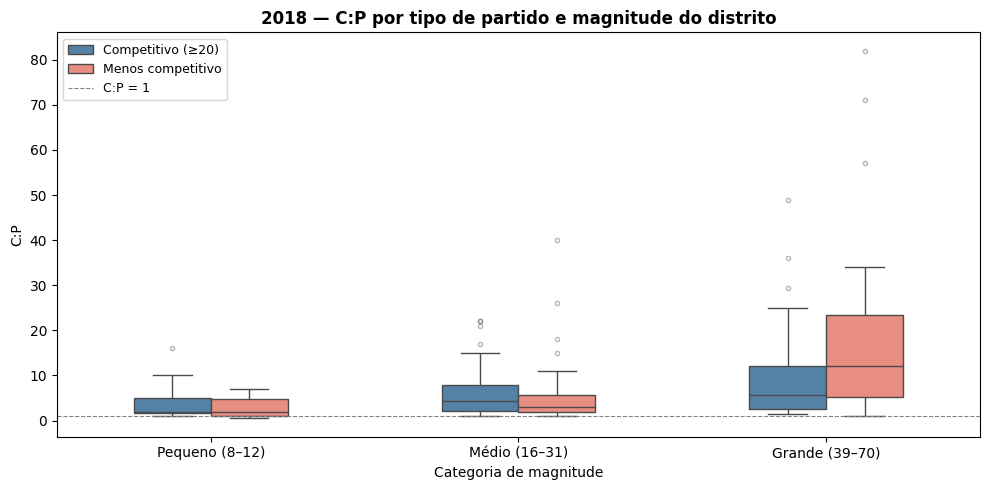

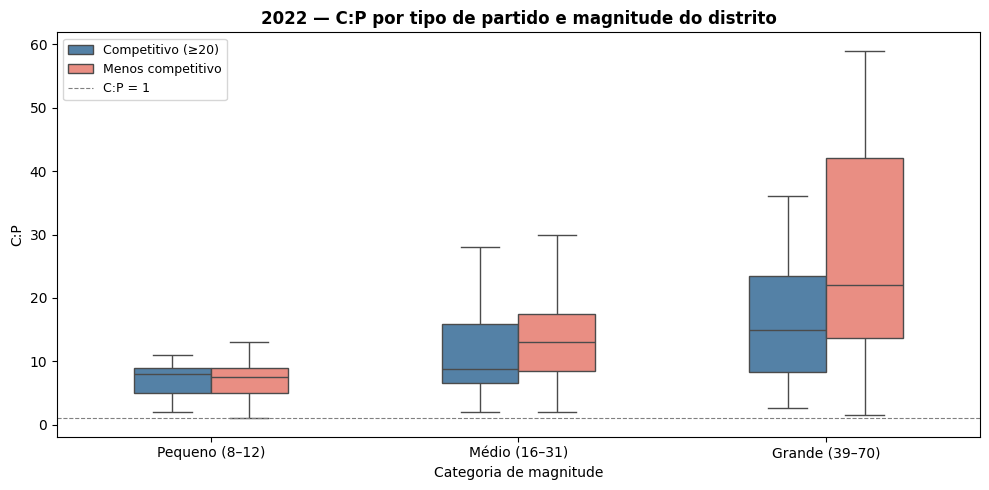

In [10]:
# Boxplot C:P por tipo de partido e magnitude
for ano in [2018, 2022]:
    sub = listas2.loc[(listas2['ano_eleicao'] == ano) & listas2['razao_cp'].notna()
                      & listas2['dm_cat'].notna()]
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=sub, x='dm_cat', y='razao_cp', hue='tipo_partido',
        palette={'Competitivo (≥20)':'steelblue', 'Menos competitivo':'salmon'},
        width=0.5, flierprops={'markersize':3,'alpha':0.4}, ax=ax
    )
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='C:P = 1')
    ax.set_xlabel('Categoria de magnitude')
    ax.set_ylabel('C:P')
    ax.set_title(f'{ano} — C:P por tipo de partido e magnitude do distrito', fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

## 5. Recorte por UF

In [11]:
uf_stats = (
    listas.groupby(['ano_eleicao','sg_uf'])
    .agg(
        qt_vaga      = ('qt_vaga', 'first'),
        n_listas     = ('sg_partido', 'count'),
        n_cands_med  = ('n_cands', 'mean'),
        razao_cm_med = ('razao_cm', 'mean'),
        razao_cm_p50 = ('razao_cm', 'median'),
        razao_cp_med = ('razao_cp', 'mean'),
        razao_cp_p50 = ('razao_cp', 'median'),
        razao_cp_n   = ('razao_cp', 'count'),   # listas com P > 0
        prop_limite_med = ('prop_limite', 'mean'),
    )
    .round(3)
    .reset_index()
    .sort_values(['ano_eleicao','qt_vaga'], ascending=[True,False])
)

for ano in [2018, 2022]:
    print(f"\n{'='*65}  {ano}")
    display(
        uf_stats.loc[uf_stats['ano_eleicao'] == ano]
        .set_index('sg_uf')
    )


=================================================================  2018


,ano_eleicao,qt_vaga,n_listas,n_cands_med,razao_cm_med,razao_cm_p50,razao_cp_med,razao_cp_p50,razao_cp_n,prop_limite_med
sg_uf,,,,,,,,,,
SP,2018,70,34,43.618,0.623,0.629,13.893,7.200,15,0.415
MG,2018,53,34,24.265,0.458,0.377,13.935,8.000,17,0.305
RJ,2018,46,33,31.697,0.689,0.630,18.033,12.000,14,0.459
BA,2018,39,33,13.545,0.347,0.231,7.128,2.500,13,0.232
RS,2018,31,33,12.242,0.395,0.258,9.602,7.333,10,0.263
PR,2018,30,33,12.576,0.419,0.300,9.549,4.000,12,0.279
PE,2018,25,33,9.879,0.395,0.320,4.508,4.000,11,0.263
CE,2018,22,31,7.387,0.336,0.227,7.083,5.000,12,0.224
MA,2018,18,33,5.667,0.315,0.222,5.364,4.000,11,0.210



=================================================================  2022


,ano_eleicao,qt_vaga,n_listas,n_cands_med,razao_cm_med,razao_cm_p50,razao_cp_med,razao_cp_p50,razao_cp_n,prop_limite_med
sg_uf,,,,,,,,,,
SP,2022,70,32,44.656,0.638,0.786,23.592,17.708,14,0.425
MG,2022,53,32,32.344,0.610,0.745,24.588,22.500,15,0.407
RJ,2022,46,30,34.133,0.742,0.924,27.190,24.500,14,0.495
BA,2022,39,29,23.069,0.592,0.667,13.424,13.000,9,0.394
RS,2022,31,29,17.655,0.570,0.742,12.958,10.417,10,0.380
PR,2022,30,30,20.000,0.667,0.783,16.856,15.000,11,0.444
PE,2022,25,31,13.452,0.538,0.560,10.180,9.750,10,0.359
CE,2022,22,28,12.500,0.568,0.705,12.317,13.500,10,0.379
MA,2022,18,29,11.172,0.621,0.667,11.667,13.000,9,0.414


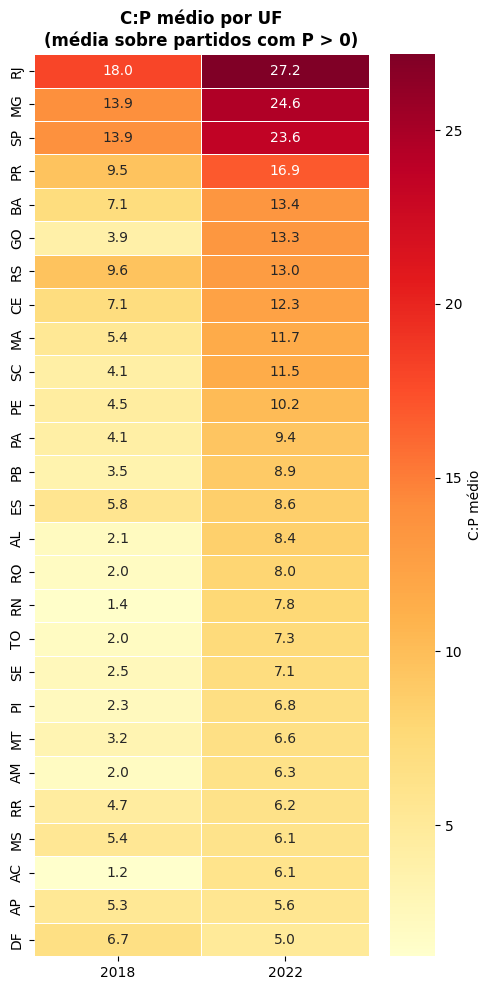

In [12]:
# Heatmap C:P médio por UF e ano
pivot_cp = uf_stats.pivot(index='sg_uf', columns='ano_eleicao', values='razao_cp_med')
pivot_cp = pivot_cp.sort_values(2022, ascending=False)

fig, ax = plt.subplots(figsize=(5, 10))
sns.heatmap(
    pivot_cp, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'C:P médio'}
)
ax.set_title('C:P médio por UF\n(média sobre partidos com P > 0)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

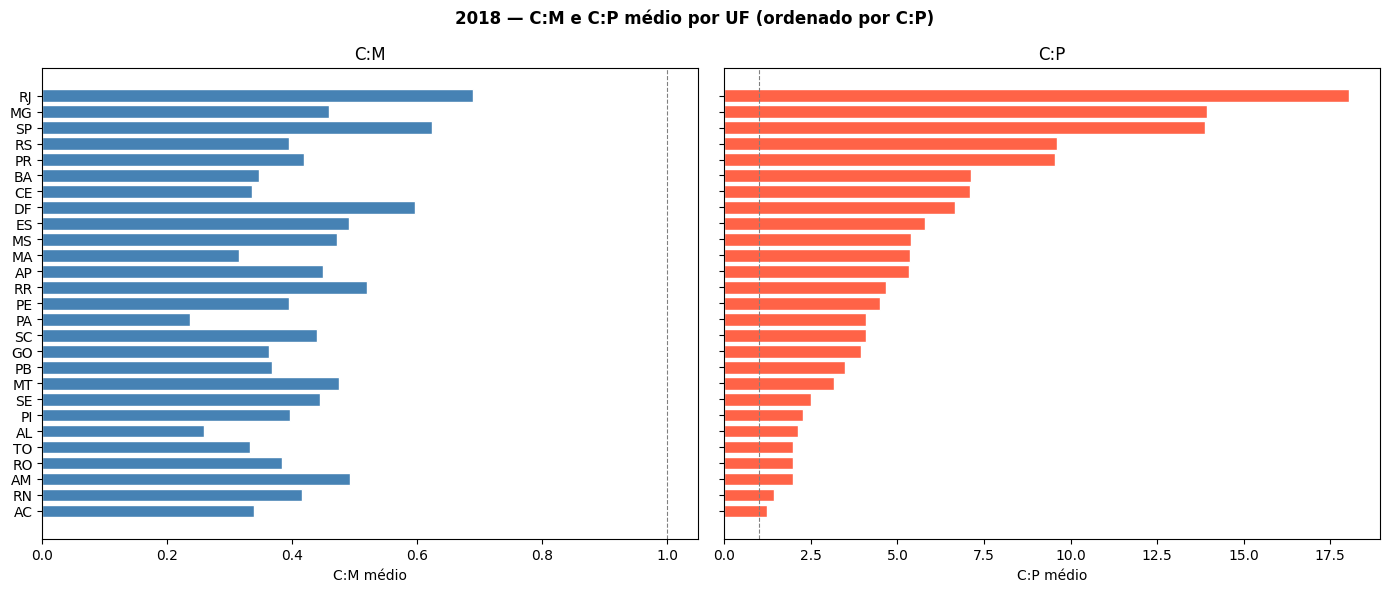

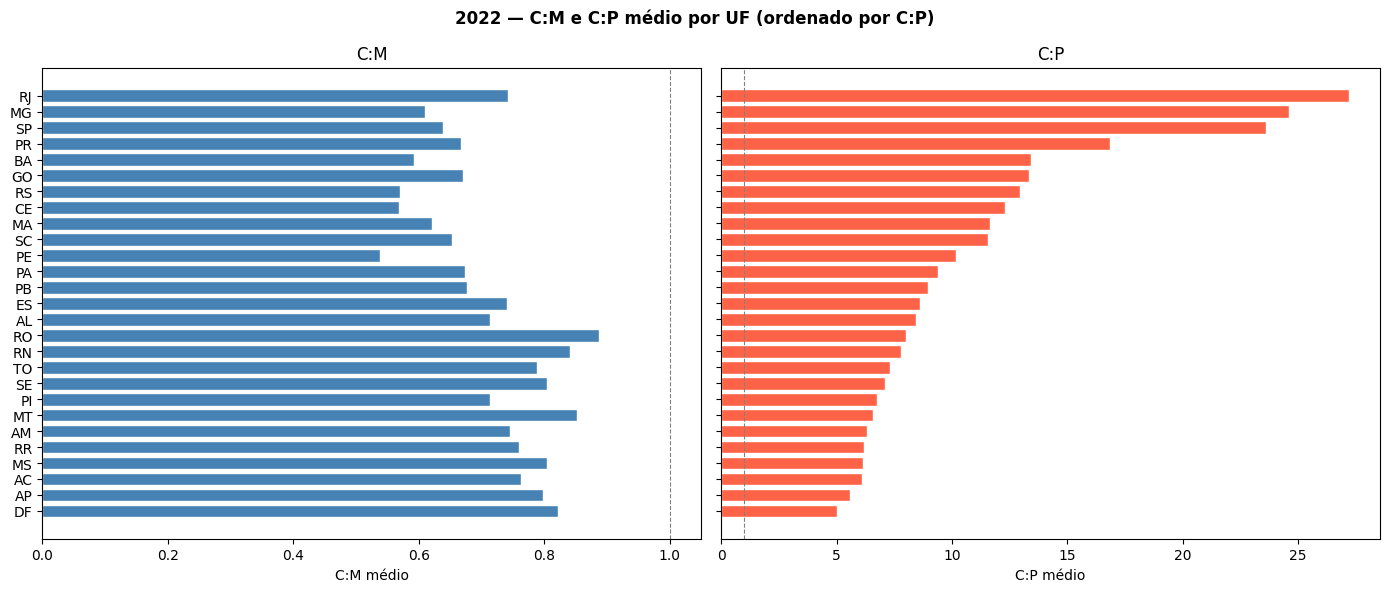

In [13]:
# Barplot comparativo UF: C:M vs C:P
for ano in [2018, 2022]:
    sub = uf_stats.loc[uf_stats['ano_eleicao'] == ano].sort_values('razao_cp_med')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    for ax, (col, label, color) in zip(axes, [
        ('razao_cm_med', 'C:M', 'steelblue'),
        ('razao_cp_med', 'C:P', 'tomato')
    ]):
        ax.barh(sub['sg_uf'], sub[col], color=color, edgecolor='white')
        ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8)
        ax.set_xlabel(f'{label} médio')
        ax.set_title(label)
    fig.suptitle(f'{ano} — C:M e C:P médio por UF (ordenado por C:P)', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Recorte por partido

In [14]:
MIN_UFS = 10

partido_stats = (
    listas.groupby(['ano_eleicao','sg_partido'])
    .agg(
        n_ufs           = ('sg_uf', 'count'),
        n_cands_total   = ('n_cands', 'sum'),
        n_eleitos_total = ('n_eleitos', 'sum'),
        p_total         = ('p_esperado', 'sum'),
        razao_cm_med    = ('razao_cm', 'mean'),
        razao_cm_p50    = ('razao_cm', 'median'),
        razao_cp_med    = ('razao_cp', 'mean'),
        razao_cp_p50    = ('razao_cp', 'median'),
        razao_cp_n      = ('razao_cp', 'count'),
        prop_limite_med = ('prop_limite', 'mean'),
    )
    .reset_index()
)

partido_filtrado = partido_stats.loc[partido_stats['n_ufs'] >= MIN_UFS].copy().round(3)

for ano in [2018, 2022]:
    print(f"\n{'='*60}  {ano}  (partidos em >= {MIN_UFS} UFs)")
    display(
        partido_filtrado
        .loc[partido_filtrado['ano_eleicao'] == ano]
        .sort_values('razao_cp_med', ascending=False)
        .set_index('sg_partido')
    )


============================================================  2018  (partidos em >= 10 UFs)


,ano_eleicao,n_ufs,n_cands_total,n_eleitos_total,p_total,razao_cm_med,razao_cm_p50,razao_cp_med,razao_cp_p50,razao_cp_n,prop_limite_med
sg_partido,,,,,,,,,,,
PSOL,2018,27,501,10,5.0,0.923,0.957,38.222,18.000,3,0.615
PTC,2018,25,199,2,2.0,0.368,0.250,23.500,23.500,2,0.246
PSL,2018,27,434,52,1.0,0.781,0.829,21.000,21.000,1,0.521
PRP,2018,25,254,4,3.0,0.442,0.300,21.000,5.000,3,0.294
PHS,2018,27,296,6,5.0,0.505,0.400,20.800,10.000,5,0.337
PV,2018,27,260,4,8.0,0.489,0.320,17.733,14.000,5,0.326
PDT,2018,27,269,28,20.0,0.504,0.375,11.729,7.333,16,0.336
PC do B,2018,27,119,9,10.0,0.285,0.222,7.667,4.000,9,0.190
PSC,2018,27,173,7,13.0,0.297,0.240,6.667,3.500,9,0.198



============================================================  2022  (partidos em >= 10 UFs)


,ano_eleicao,n_ufs,n_cands_total,n_eleitos_total,p_total,razao_cm_med,razao_cm_p50,razao_cp_med,razao_cp_p50,razao_cp_n,prop_limite_med
sg_partido,,,,,,,,,,,
PMN,2022,15,266,0,1.0,0.817,0.840,53.000,53.000,1,0.545
DC,2022,21,218,0,1.0,0.619,0.667,44.000,44.000,1,0.413
PSC,2022,23,404,6,7.0,0.887,0.944,26.429,24.000,7,0.592
PODE,2022,26,481,12,11.0,0.941,1.000,23.963,22.000,9,0.627
PROS,2022,22,340,3,7.0,0.725,0.778,22.375,20.750,4,0.483
SOLIDARIEDADE,2022,24,373,4,10.0,0.796,0.775,19.900,11.000,10,0.530
AVANTE,2022,21,396,7,7.0,0.896,1.000,19.750,15.500,4,0.597
PSOL,2022,27,305,12,10.0,0.586,0.609,17.533,15.000,5,0.391
NOVO,2022,17,210,3,8.0,0.485,0.566,14.733,15.000,5,0.323


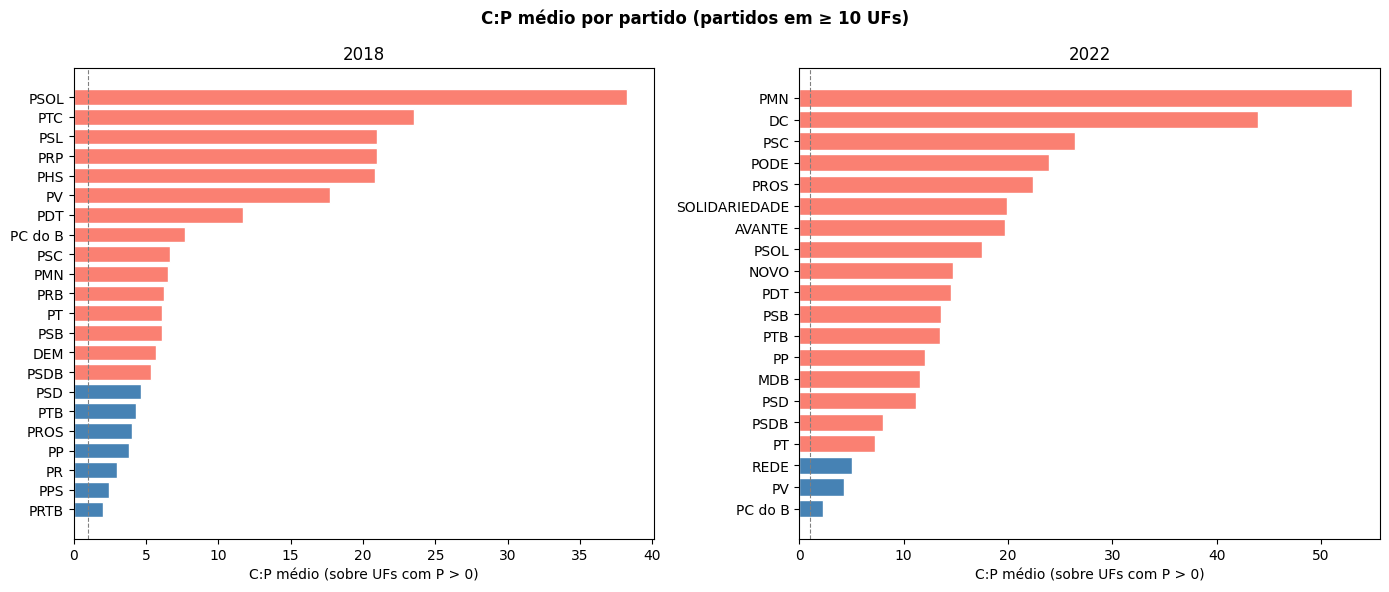

In [15]:
# Barplot C:P médio por partido
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, ano in zip(axes, [2018, 2022]):
    sub = (
        partido_filtrado
        .loc[partido_filtrado['ano_eleicao'] == ano]
        .dropna(subset=['razao_cp_med'])
        .sort_values('razao_cp_med')
    )
    colors = ['steelblue' if v <= 5 else 'salmon' for v in sub['razao_cp_med']]
    ax.barh(sub['sg_partido'], sub['razao_cp_med'], color=colors, edgecolor='white')
    ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('C:P médio (sobre UFs com P > 0)')
    ax.set_title(f'{ano}')

fig.suptitle('C:P médio por partido (partidos em ≥ 10 UFs)', fontweight='bold')
plt.tight_layout()
plt.show()

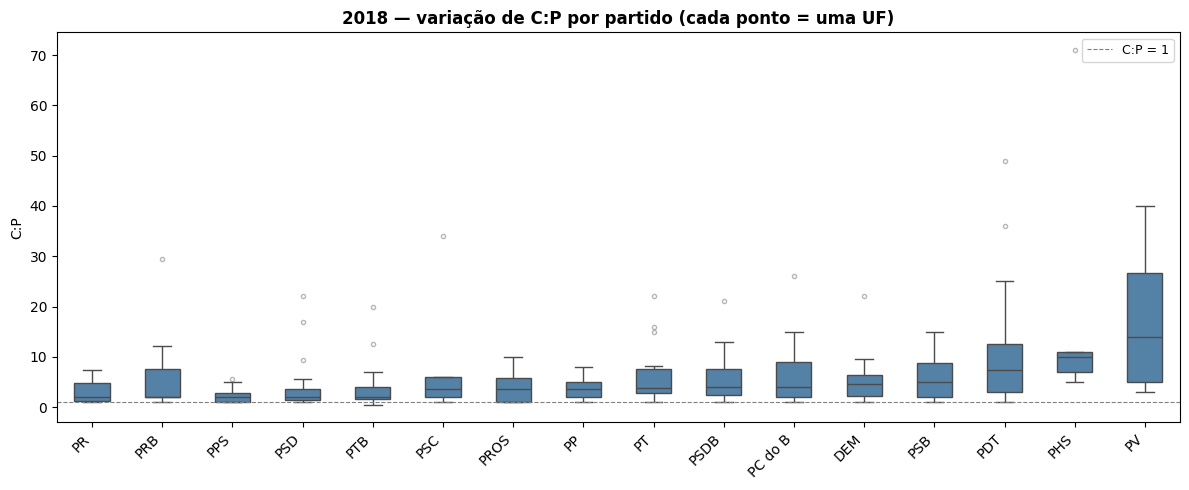

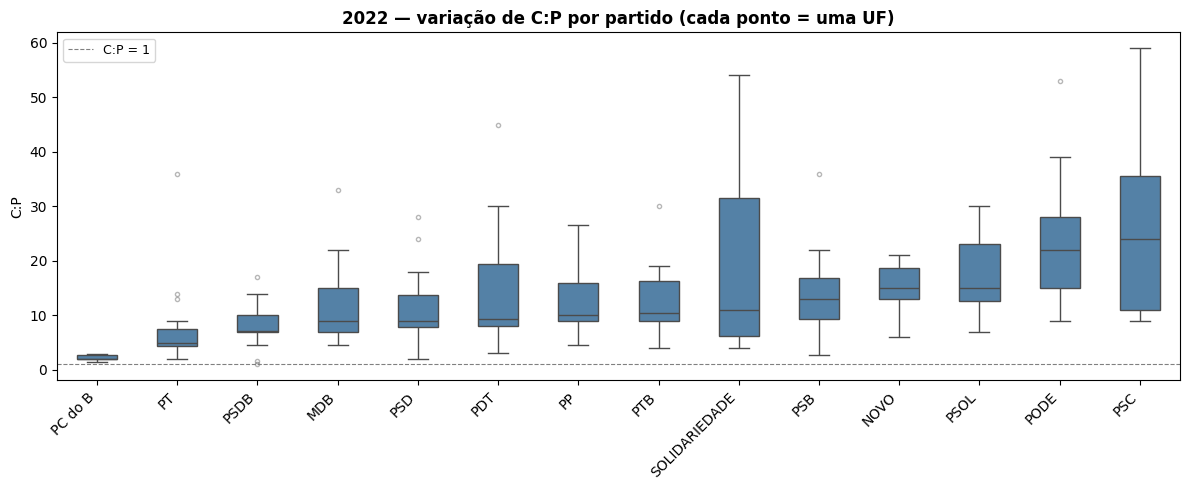

In [16]:
# Boxplot: variação de C:P entre UFs para cada partido
for ano in [2018, 2022]:
    partidos_ok = partido_filtrado.loc[
        (partido_filtrado['ano_eleicao'] == ano) &
        (partido_filtrado['razao_cp_n'] >= 5),
        'sg_partido'
    ].tolist()
    sub = listas.loc[
        (listas['ano_eleicao'] == ano) &
        (listas['sg_partido'].isin(partidos_ok)) &
        listas['razao_cp'].notna()
    ]
    ordem = sub.groupby('sg_partido')['razao_cp'].median().sort_values().index

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data=sub, x='sg_partido', y='razao_cp', order=ordem,
        color='steelblue', width=0.5,
        flierprops={'markersize':3,'alpha':0.4}, ax=ax
    )
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='C:P = 1')
    ax.set_ylabel('C:P')
    ax.set_xlabel('')
    ax.set_title(f'{ano} — variação de C:P por partido (cada ponto = uma UF)', fontweight='bold')
    ax.legend(fontsize=9)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. M vs. C:M vs. C:P como proxies

As três proxies capturam dimensões distintas. M é constante dentro do distrito;
C:M adiciona variação entre partidos no mesmo distrito; C:P acrescenta a escala
de força do partido. Um R² baixo de C:P regredido sobre M confirma que M não
é proxy adequado para o conceito de Carey & Shugart.

In [17]:
print("R²  e  coeficiente de M ao regredir cada proxy sobre M:\n")
for ano in [2018, 2022]:
    print(f"--- {ano} ---")
    sub = listas.loc[listas['ano_eleicao'] == ano].dropna(subset=['razao_cp'])
    X = sm.add_constant(sub['qt_vaga'])
    for col, label in [('razao_cm','C:M'), ('razao_cp','C:P')]:
        r = sm.OLS(sub[col], X).fit(cov_type='HC3')
        print(f"  {label} ~ M | R²={r.rsquared:.4f}  β_M={r.params['qt_vaga']:.5f}  "
              f"p={r.pvalues['qt_vaga']:.4f}")
    print()

R²  e  coeficiente de M ao regredir cada proxy sobre M:

--- 2018 ---
  C:M ~ M | R²=0.0062  β_M=0.00153  p=0.2904
  C:P ~ M | R²=0.1573  β_M=0.22011  p=0.0001

--- 2022 ---
  C:M ~ M | R²=0.0292  β_M=-0.00247  p=0.0160
  C:P ~ M | R²=0.3181  β_M=0.33262  p=0.0000



In [18]:
# Variância de C:P dentro de cada nível de M (mostra que M não substitui C:P)
var_dentro_M = (
    listas.dropna(subset=['razao_cp'])
    .groupby(['ano_eleicao','qt_vaga'])['razao_cp']
    .agg(['std','mean','count'])
    .reset_index()
    .rename(columns={'std':'std_cp','mean':'mean_cp','count':'n'})
)

print("CV médio de C:P dentro de cada nível de M:")
for ano in [2018, 2022]:
    sub = var_dentro_M.loc[var_dentro_M['ano_eleicao'] == ano].dropna()
    cv = np.average(sub['std_cp'] / sub['mean_cp'], weights=sub['n'])
    print(f"  {ano}: CV = {cv:.3f}")

CV médio de C:P dentro de cada nível de M:
  2018: CV = 0.985
  2022: CV = 0.519


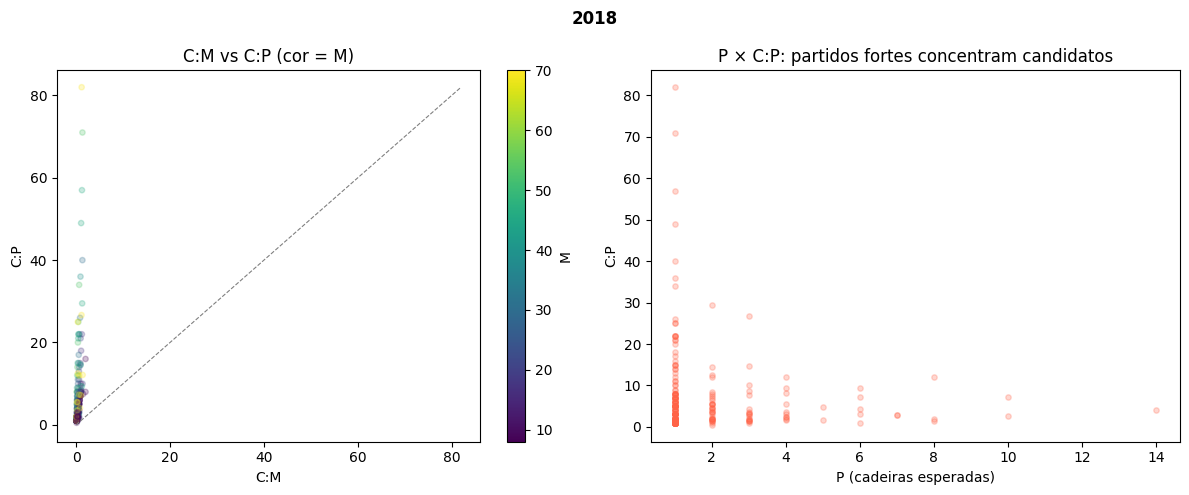

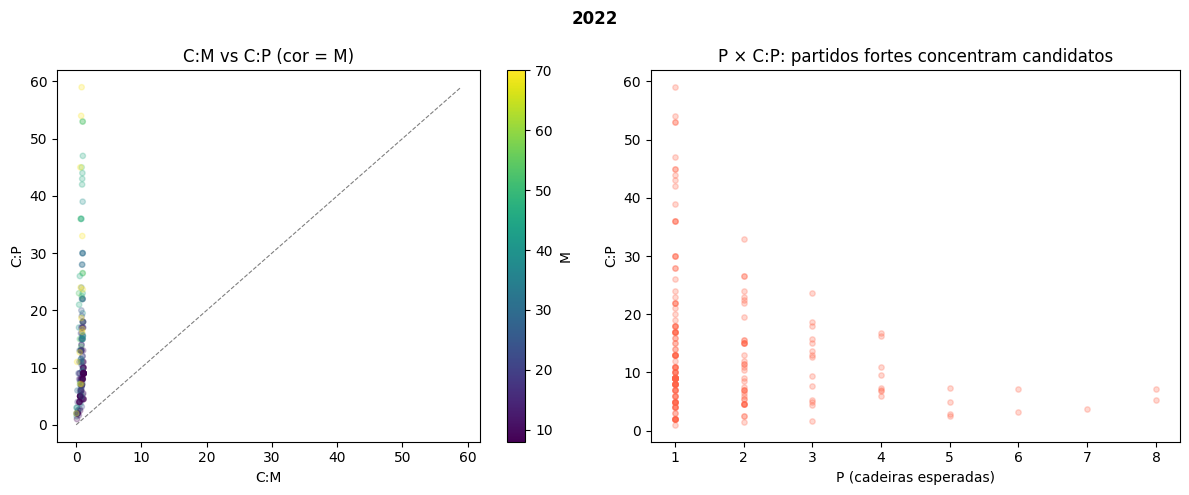

In [19]:
# Scatter triangular: M, C:M e C:P para 2022
for ano in [2018, 2022]:
    sub = listas2.loc[
        (listas2['ano_eleicao'] == ano) & listas2['razao_cp'].notna()
    ]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # C:M vs C:P: o quanto diferem
    axes[0].scatter(sub['razao_cm'], sub['razao_cp'], alpha=0.25, s=15,
                    c=sub['qt_vaga'], cmap='viridis')
    axes[0].plot([0, sub[['razao_cm','razao_cp']].max().max()],
                 [0, sub[['razao_cm','razao_cp']].max().max()],
                 color='gray', linestyle='--', linewidth=0.8, label='C:M = C:P')
    axes[0].set_xlabel('C:M')
    axes[0].set_ylabel('C:P')
    axes[0].set_title('C:M vs C:P (cor = M)')
    sm_obj = plt.cm.ScalarMappable(cmap='viridis')
    sm_obj.set_array(sub['qt_vaga'])
    plt.colorbar(sm_obj, ax=axes[0], label='M')

    # C:P por força do partido (p_esperado)
    axes[1].scatter(sub['p_esperado'], sub['razao_cp'], alpha=0.25, s=15, color='tomato')
    axes[1].set_xlabel('P (cadeiras esperadas)')
    axes[1].set_ylabel('C:P')
    axes[1].set_title('P × C:P: partidos fortes concentram candidatos')

    fig.suptitle(f'{ano}', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Tabela exportável: C:P por partido × UF

In [20]:
wide = (
    listas[['sg_partido','sg_uf','ano_eleicao',
            'n_cands','qt_vaga','p_esperado','razao_cm','razao_cp']]
    .pivot_table(index=['sg_partido','sg_uf'], columns='ano_eleicao',
                 values=['n_cands','p_esperado','razao_cm','razao_cp'])
    .round(3)
)
wide.columns = ['_'.join(map(str,c)) for c in wide.columns]
wide = wide.reset_index()
wide['delta_cp'] = (wide.get('razao_cp_2022',np.nan) - wide.get('razao_cp_2018',np.nan)).round(3)

print(f"{len(wide):,} combinações partido×UF")
wide.sort_values('razao_cp_2022', ascending=False, na_position='last').head(20)

1,053 combinações partido×UF


,sg_partido,sg_uf,n_cands_2018,n_cands_2022,p_esperado_2018,p_esperado_2022,razao_cm_2018,razao_cm_2022,razao_cp_2018,razao_cp_2022,delta_cp
698,PSC,SP,3.0,59.0,3.0,1.0,0.043,0.843,1.0,59.0,58.0
1012,SOLIDARIEDADE,SP,45.0,54.0,NaN,1.0,0.643,0.771,NaN,54.0,NaN
394,PMN,MG,12.0,53.0,1.0,1.0,0.226,1.000,12.0,53.0,41.0
421,PODE,MG,26.0,53.0,NaN,1.0,0.491,1.000,NaN,53.0,NaN
1005,SOLIDARIEDADE,RJ,29.0,47.0,NaN,1.0,0.630,1.022,NaN,47.0,NaN
308,PDT,SP,25.0,45.0,1.0,1.0,0.357,0.643,25.0,45.0,20.0
683,PSC,MG,34.0,45.0,1.0,1.0,0.642,0.849,34.0,45.0,11.0
89,DC,RJ,44.0,44.0,NaN,1.0,0.957,0.957,NaN,44.0,NaN
39,AVANTE,RJ,48.0,43.0,NaN,1.0,1.043,0.935,NaN,43.0,NaN
586,PROS,RJ,11.0,42.0,2.0,1.0,0.239,0.913,5.5,42.0,36.5
